In [2]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import yfinance as yf
import torch.optim as optim
import torch.functional as F
from torchviz import make_dot
from tqdm.notebook import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt
from torchsummary import summary
from IPython.display import Image
import plotly.graph_objects as go
from keras.utils import plot_model
from keras.models import Sequential
from IPython.display import Image, display
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout

In [3]:
tck= yf.Ticker("GOOG")

# Defining the start date
start_date= "2016-06-14"

# Historical Data
df= tck.history(start= start_date, end=None)
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-06-14 00:00:00-04:00,35.736238,36.035004,35.568647,35.825520,26122000,0.0,0.0
2016-06-15 00:00:00-04:00,35.861929,36.060439,35.777636,35.857937,24290000,0.0,0.0
2016-06-16 00:00:00-04:00,35.657932,35.744721,35.076858,35.430992,39650000,0.0,0.0
2016-06-17 00:00:00-04:00,35.345697,35.354179,34.338272,34.501270,68048000,0.0,0.0
2016-06-20 00:00:00-04:00,34.852907,35.037954,34.585566,34.600529,41650000,0.0,0.0
...,...,...,...,...,...,...,...
2024-10-21 00:00:00-04:00,164.580002,166.220001,164.304993,165.800003,11384000,0.0,0.0
2024-10-22 00:00:00-04:00,164.699997,167.470001,164.669998,166.820007,11958600,0.0,0.0
2024-10-23 00:00:00-04:00,166.429993,167.600006,163.632996,164.479996,12754300,0.0,0.0


In [4]:
# Move column 'Close' to the first position
col_close = df.pop('Close')
df.insert(0, 'Close', col_close)
df.head()

,Close,Open,High,Low,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-06-14 00:00:00-04:00,35.825520,35.736238,36.035004,35.568647,26122000,0.0,0.0
2016-06-15 00:00:00-04:00,35.857937,35.861929,36.060439,35.777636,24290000,0.0,0.0
2016-06-16 00:00:00-04:00,35.430992,35.657932,35.744721,35.076858,39650000,0.0,0.0
2016-06-17 00:00:00-04:00,34.501270,35.345697,35.354179,34.338272,68048000,0.0,0.0
2016-06-20 00:00:00-04:00,34.600529,34.852907,35.037954,34.585566,41650000,0.0,0.0


In [5]:
df.columns

Index(['Close', 'Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [6]:
columns=['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

In [8]:
df.shape

(2107, 7)

In [9]:
def check_df(df: object, head: object=5) -> object:
    print("\n Shape")
    print(df.shape)
    print("\n Types")
    print(df.dtypes)
    print("\n NANs")
    print(df.isnull().sum())
    print("\n Info")
    print(df.info())
check_df(df)


 Shape
(2107, 7)

 Types
Close           float64
Open            float64
High            float64
Low             float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

 NANs
Close           0
Open            0
High            0
Low             0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

 Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2107 entries, 2016-06-14 00:00:00-04:00 to 2024-10-25 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         2107 non-null   float64
 1   Open          2107 non-null   float64
 2   High          2107 non-null   float64
 3   Low           2107 non-null   float64
 4   Volume        2107 non-null   int64  
 5   Dividends     2107 non-null   float64
 6   Stock Splits  2107 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 131.7 KB
None


In [10]:
df['Volume'] = df['Volume'].astype('float64')

In [11]:
print('Number of duplicated rows: ', len(df[df.duplicated()]))

Number of duplicated rows:  0


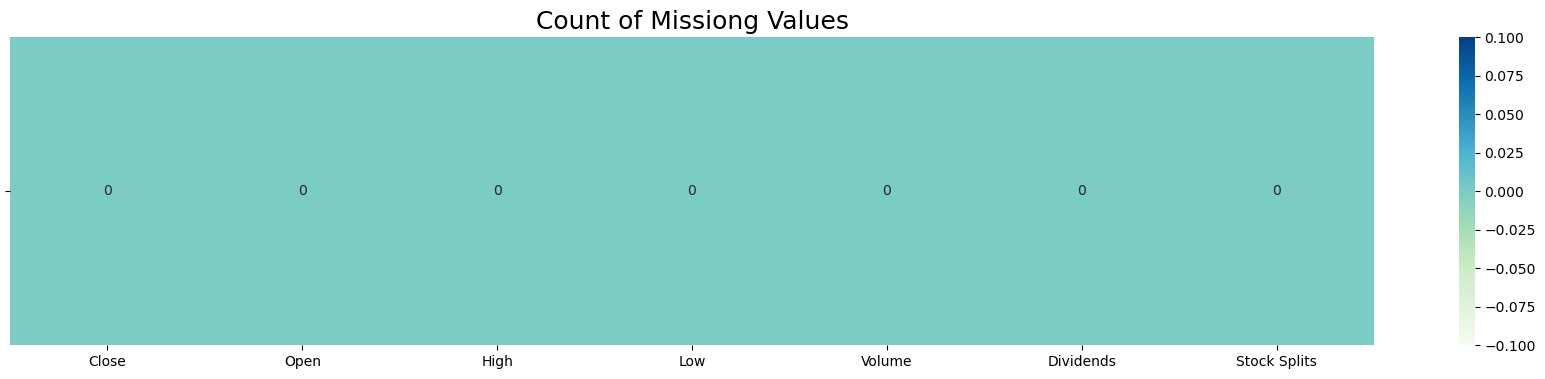

In [12]:
plt.figure(figsize=(22, 4))
sns.heatmap((df.isna().sum()).to_frame(name='').T, cmap='GnBu', annot=True, fmt='0.0f').set_title('Count of Missiong Values', fontsize=18)
plt.show()

THERE IS NO DUPLICATED ROW & NO NAN DATA.


In [13]:
df.describe().T.style.background_gradient(cmap='GnBu', axis=1)

,count,mean,std,min,25%,50%,75%,max
Close,2107.000000,89.277226,40.749023,33.331142,54.293413,75.645226,125.747688,192.406723
Open,2107.000000,89.219142,40.745260,33.467808,54.266734,75.538489,125.843954,191.497912
High,2107.000000,90.181951,41.188145,33.532651,54.944567,76.171936,126.758700,193.055862
Low,2107.000000,88.341921,40.334162,33.082954,53.611589,74.882600,124.501371,190.369396
Volume,2107.000000,29059348.457523,13269454.835556,6936000.000000,20648000.000000,25888000.000000,33343000.000000,124140000.000000
Dividends,2107.000000,0.000190,0.006160,0.000000,0.000000,0.000000,0.000000,0.200000
Stock Splits,2107.000000,0.009492,0.435710,0.000000,0.000000,0.000000,0.000000,20.000000


WE CAN SEE STATISTICAL INFORMATION IN THE TABLE ABOVE


In [14]:
# Finding Unique Data
df.apply(lambda x: len(x.unique()))

Close           2075
Open            2107
High            2107
Low             2107
Volume          2041
Dividends          2
Stock Splits       2
dtype: int64

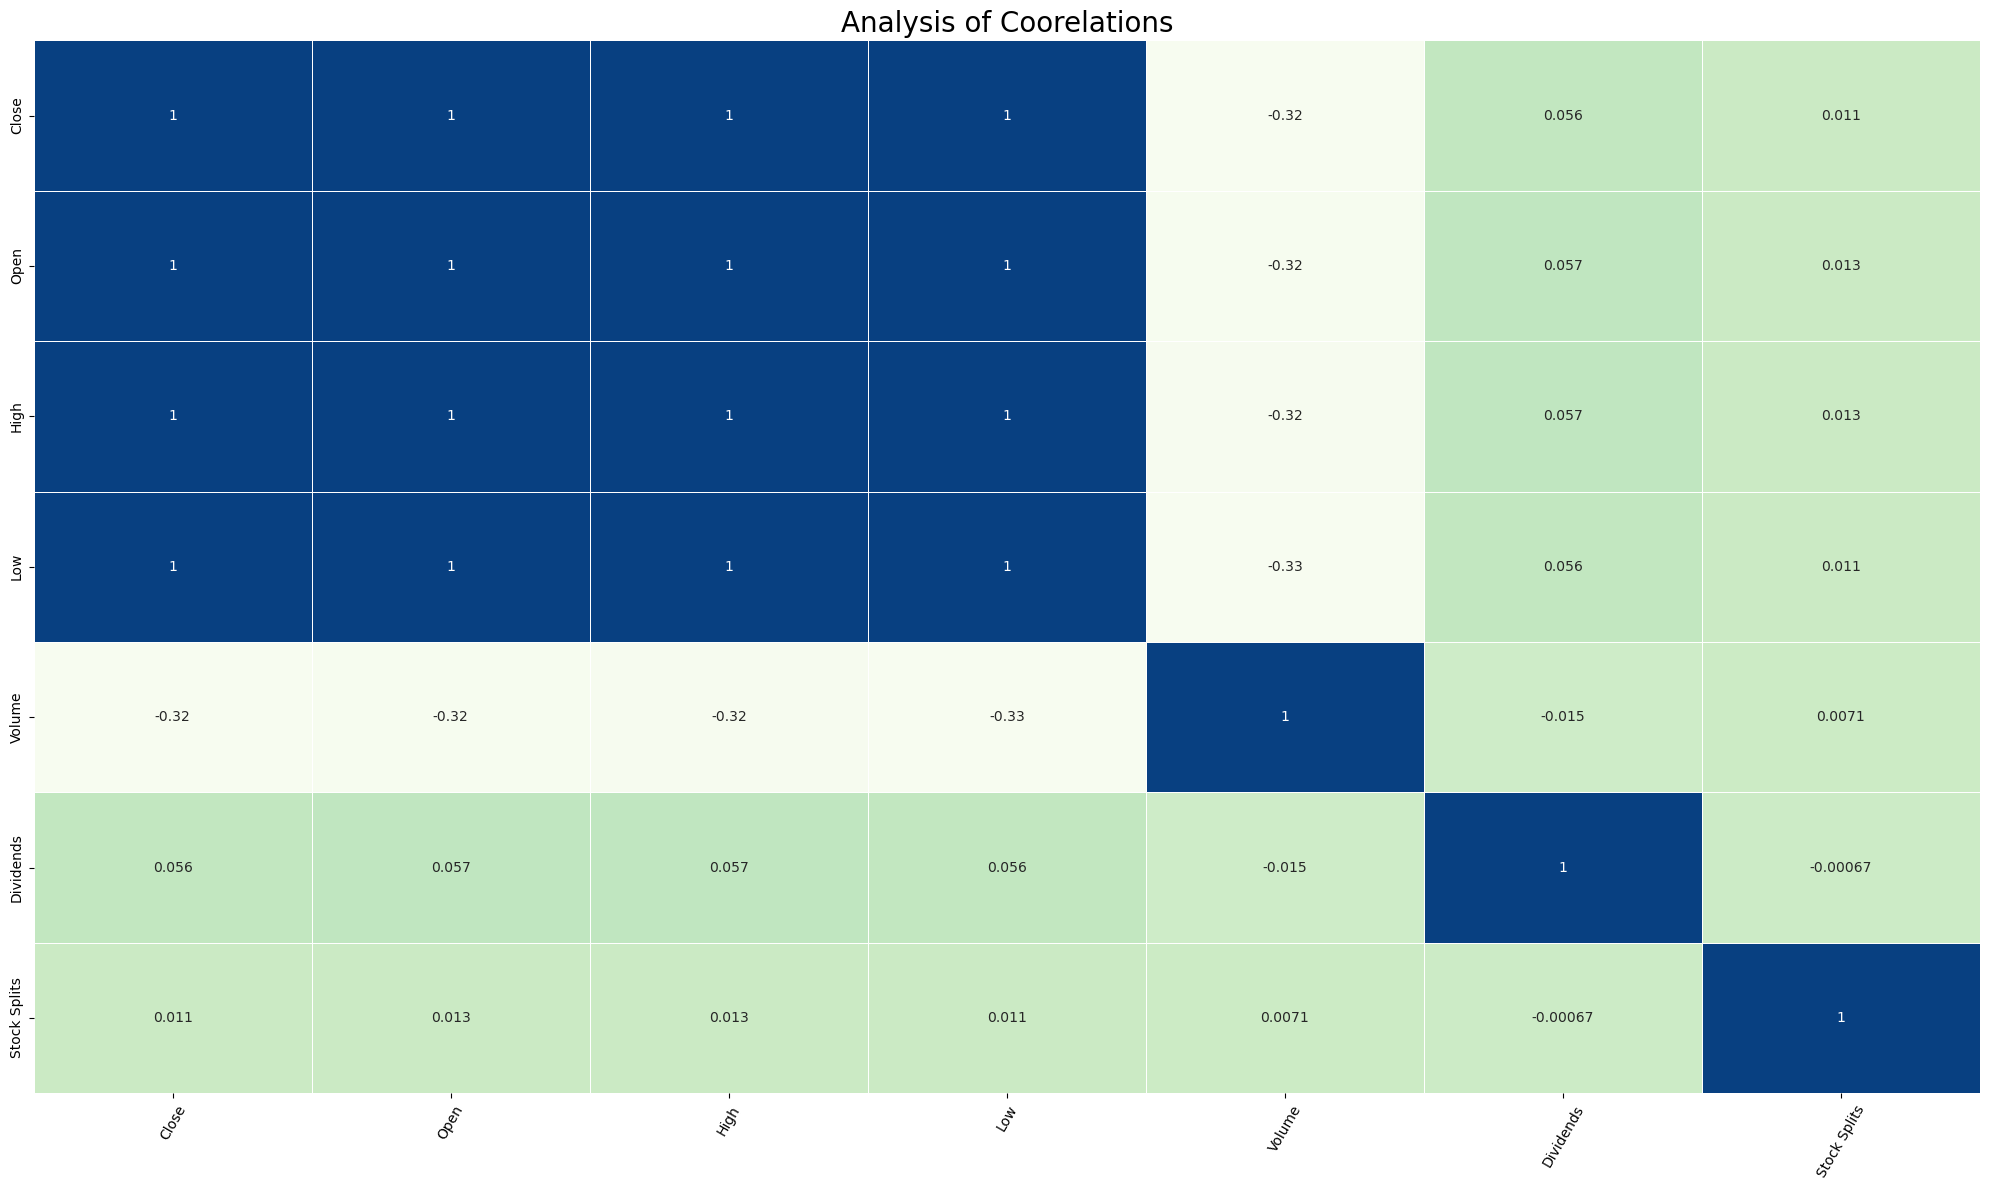

In [15]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(numeric_only=True), cmap="GnBu", annot=True, linewidths=.6, cbar=False)
plt.xticks(rotation=60, size=10)
plt.yticks(size=10)
plt.title('Analysis of Coorelations', size=20)
plt.tight_layout()
plt.show()

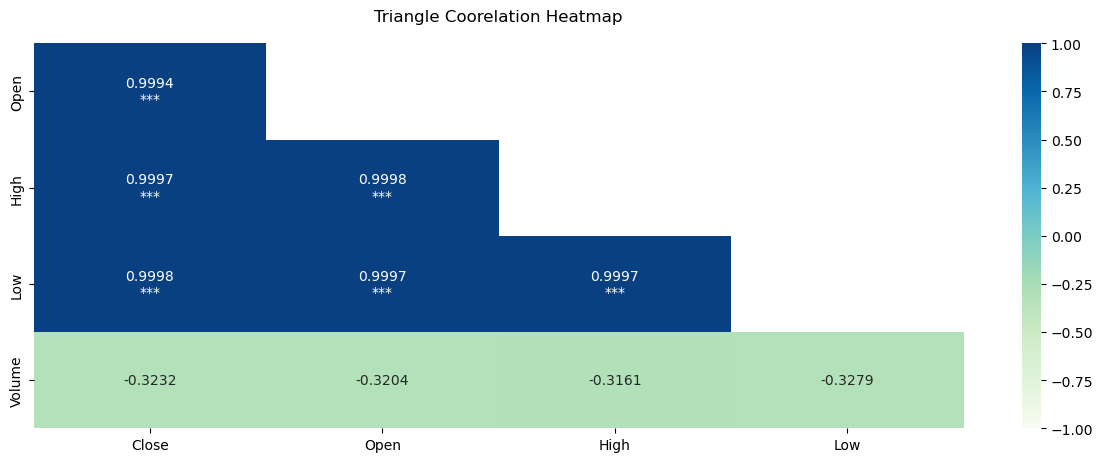

In [16]:
corr= df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(15, 5))
mask= np.triu(np.ones_like(corr, dtype=bool))
cut_off= 0.25
extreme_1= 0.5
extreme_2= 0.75
extreme_3= 0.9
mask |= np.abs(corr) < cut_off
corr= corr[~mask]
remove_empty_rows_and_cols= True
if remove_empty_rows_and_cols:
    wanted_cols= np.flatnonzero(np.count_nonzero(~mask, axis=1))
    wanted_rows= np.flatnonzero(np.count_nonzero(~mask, axis=0))
    corr= corr.iloc[wanted_cols, wanted_rows]
    
annot= [[f"{val:.4f}" + ('' if abs(val) < extreme_1 else '\n*') + ('' if abs(val) < extreme_2 else '*') + ('' if abs(val) < extreme_3 else '*')
         for val in row] for row in corr.to_numpy()]
heatmap= sns.heatmap(corr, vmin=-1, vmax=1, annot=annot, fmt='', cmap='GnBu')
heatmap.set_title('Triangle Coorelation Heatmap', fontdict={'fontsize': 12}, pad=16)
plt.show()

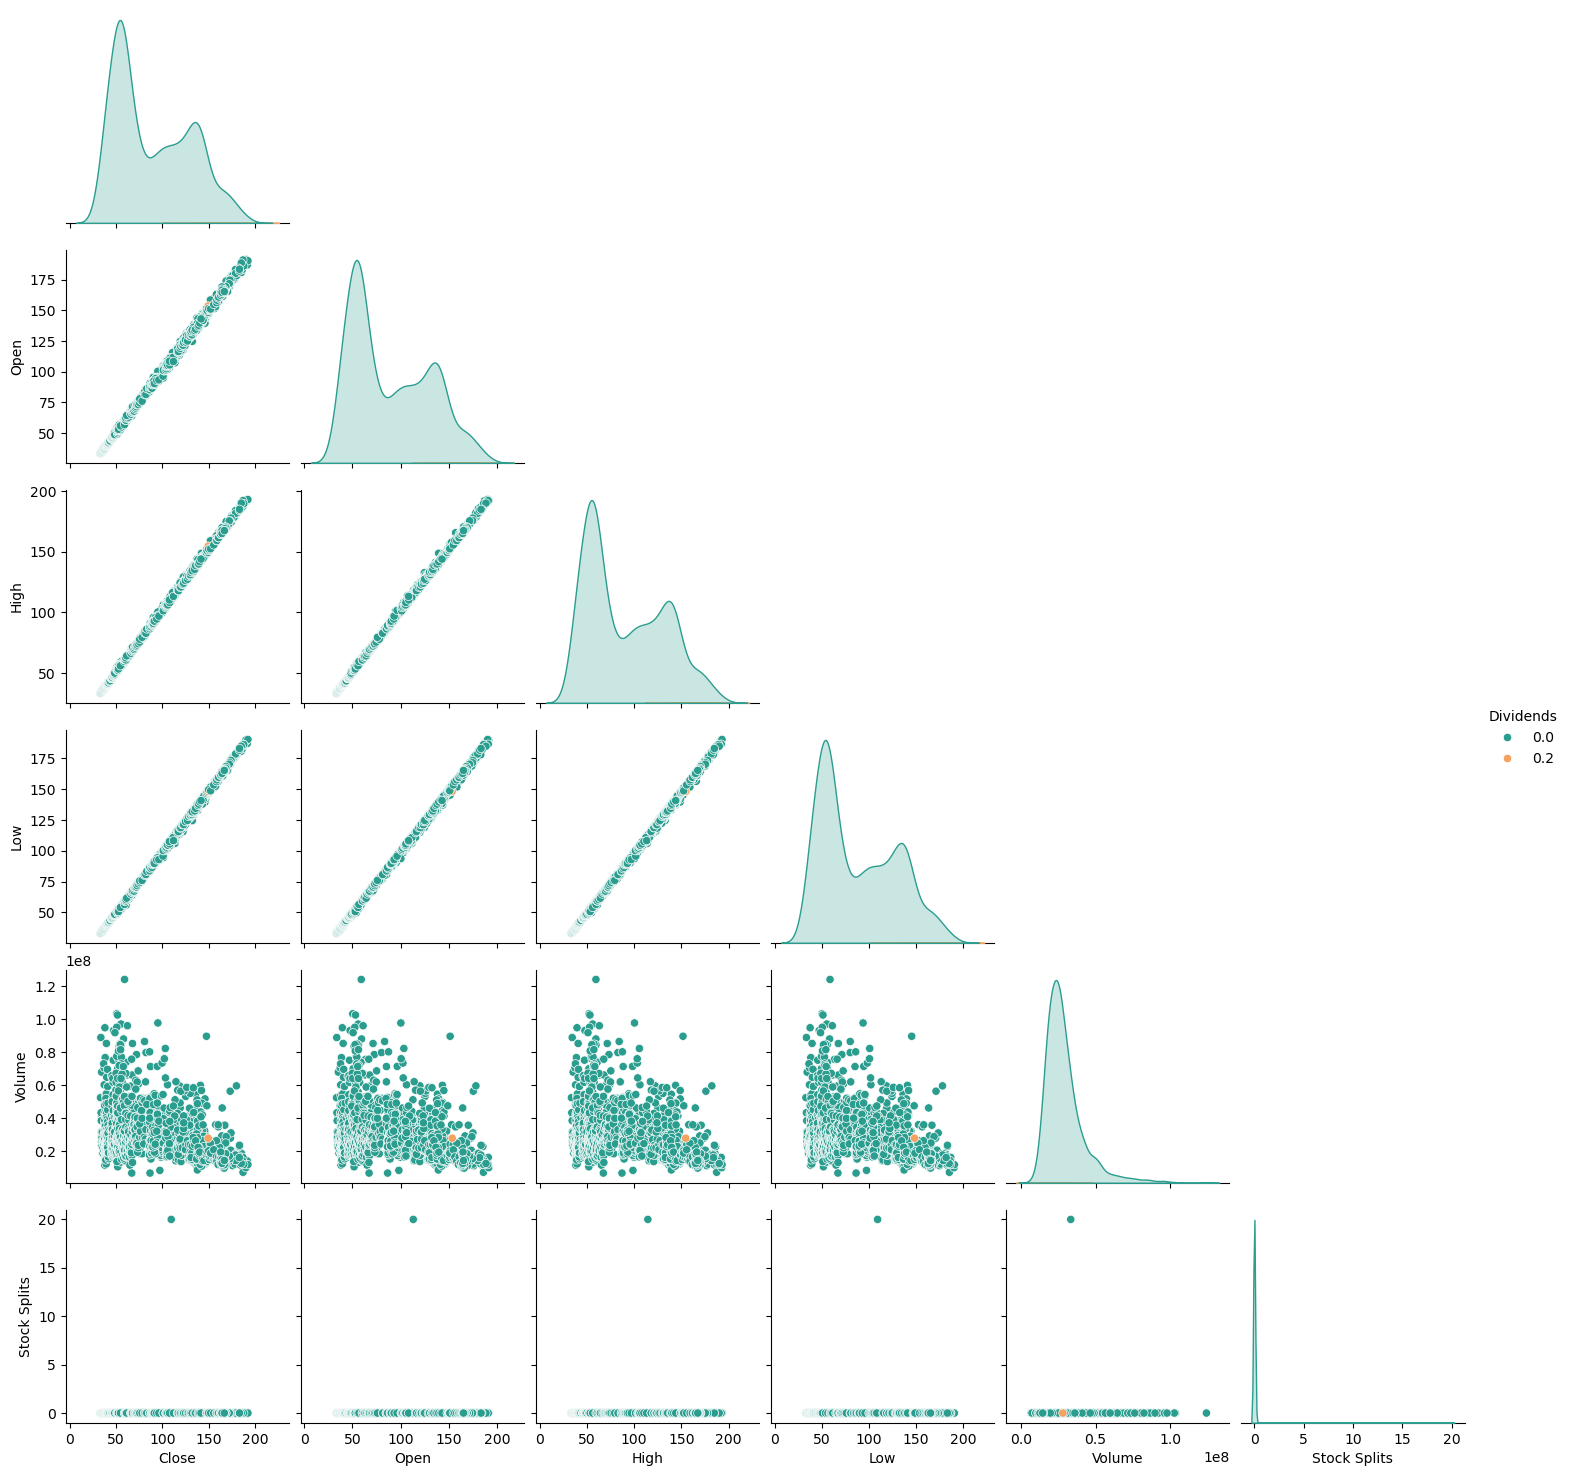

In [17]:
import warnings
warnings.filterwarnings('ignore')
custom_pallete= sns.color_palette(['#2a9d8f', '#f4a261'])
sns.pairplot(data=df, diag_kind='kde', hue='Dividends', palette=custom_pallete, corner=True)
plt.gcf().set_facecolor('#ffffff')
plt.show()

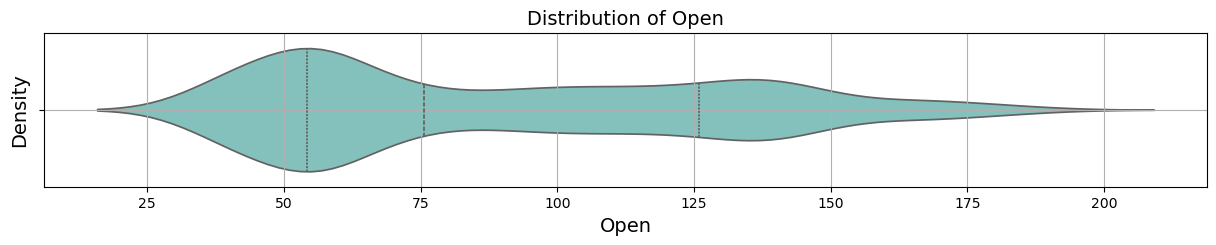

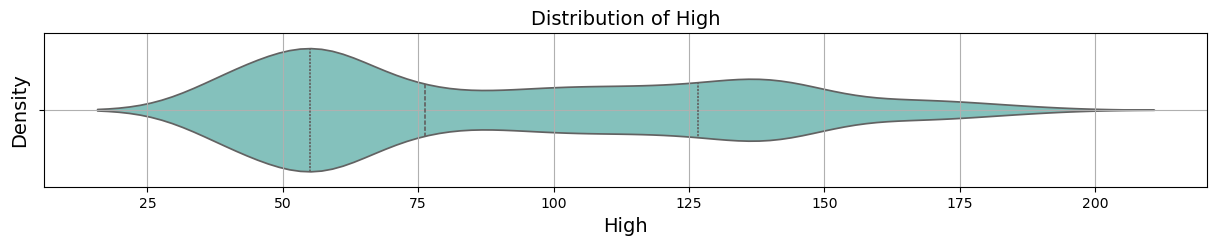

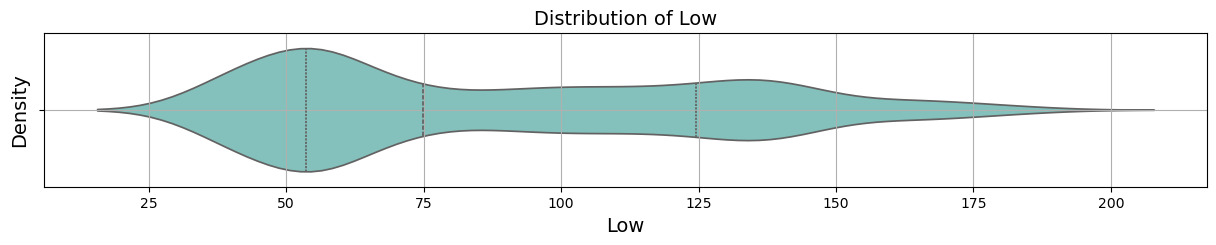

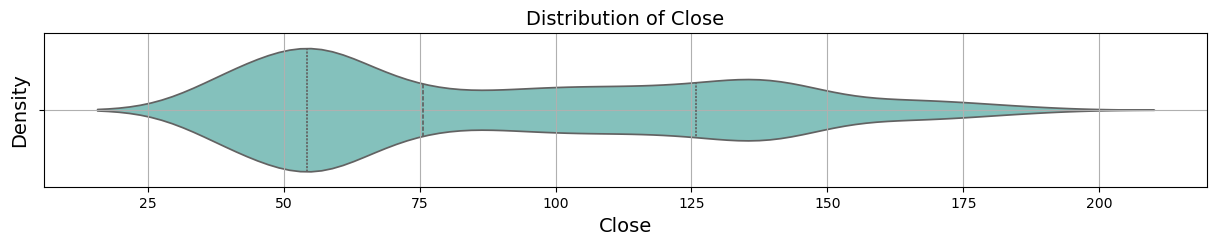

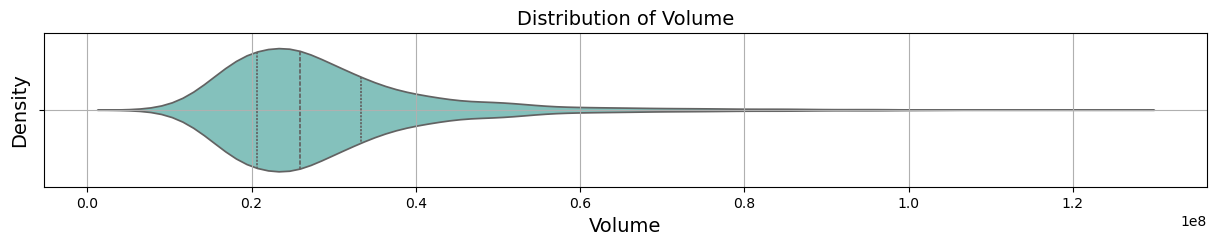

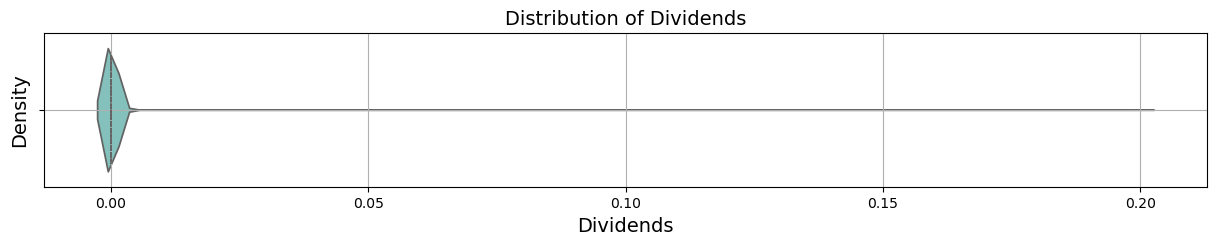

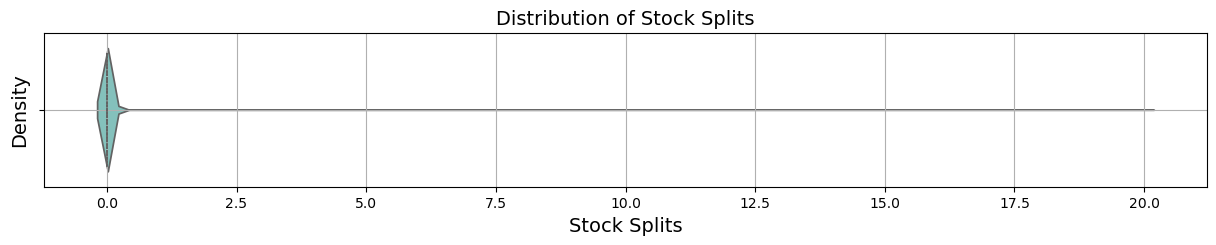

In [18]:
palette= "GnBu"
for column in columns:
    plt.figure(figsize=(15, 2))
    sns.violinplot(x=df[column], palette=palette, inner="quartile")
    plt.title(f'Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.grid(True)
    plt.show()

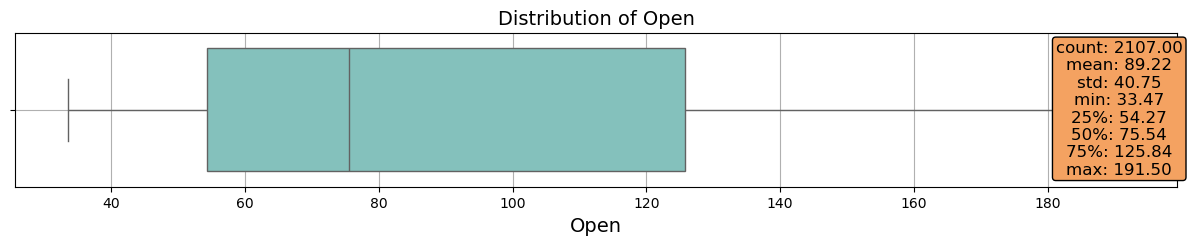

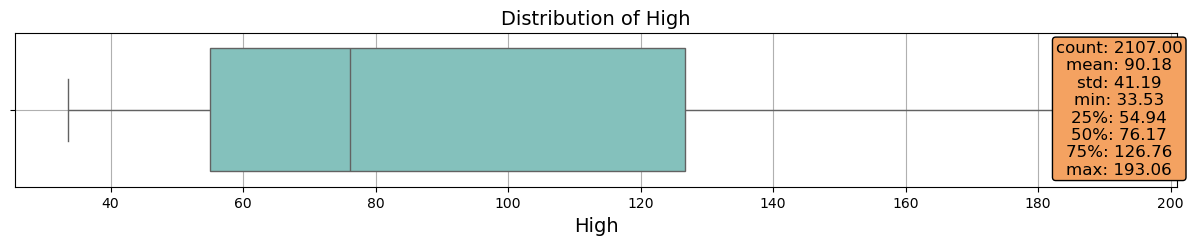

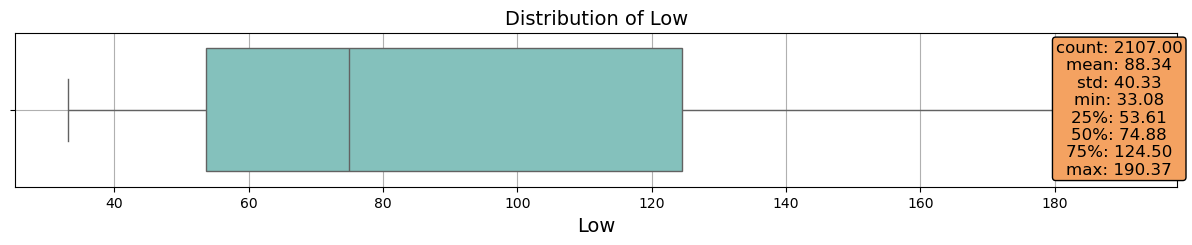

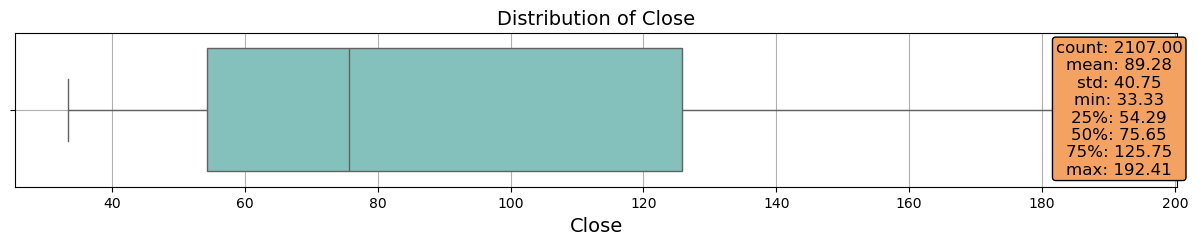

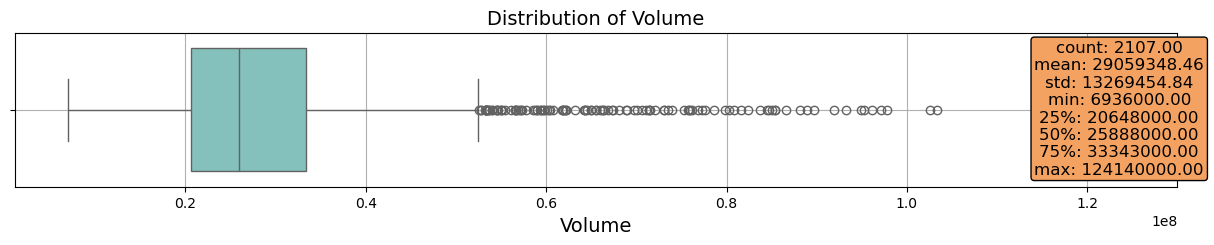

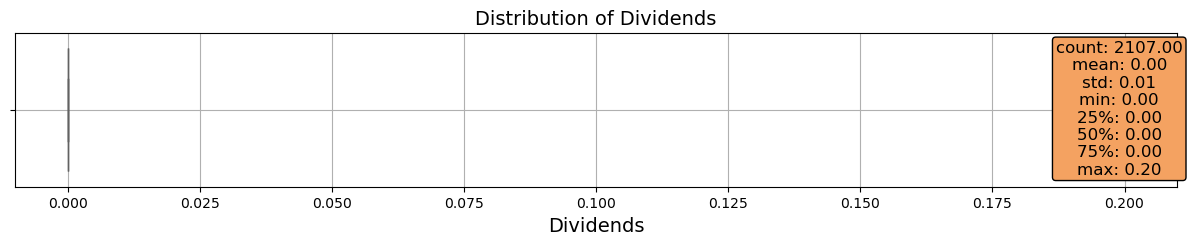

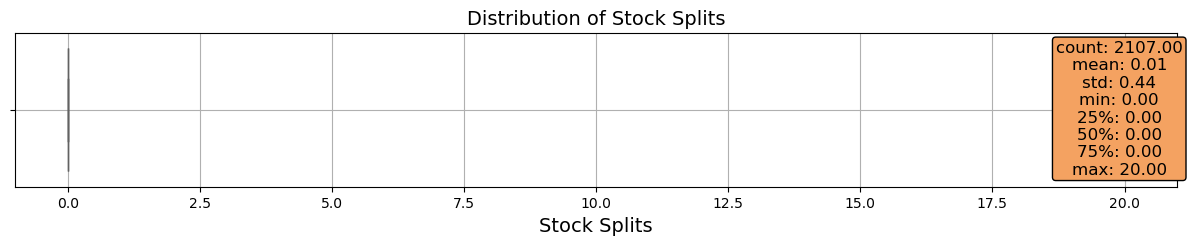

In [19]:
palette = "GnBu" 
for column in columns:
    plt.figure(figsize=(15, 2)) 
    sns.boxplot(x=df[column], palette=palette)
    plt.title(f'Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=14)
    stats = df[column].describe()
    stats_text = "\n".join([f"{key}: {value:.2f}" for key, value in stats.items()])
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', horizontalalignment='center', bbox=dict(boxstyle='round,pad=0.2', edgecolor='black', facecolor='#f4a261'))
    plt.grid(True) 
    plt.show()